# Confidence Intervals on a Real Classifier

**Hamed Seyed-Allaei**

A precision of 0.80 and a recall of 0.61 are two numbers. They are also two
numbers that would come out differently on a different test set, and nothing
about the way they are usually reported tells you by how much.

This notebook takes a public dataset, trains two ordinary models on it, and
uses `replicas` to put a confidence interval on every metric it reports. The
question it answers is the one that decides whether a model ships: *is model A
genuinely better than model B, or is the gap noise?*

Everything here runs from a clean environment. The data downloads in one call,
and the whole notebook takes about a minute.

## Install

```python
%pip install "replicas[pandas,plot]" scikit-learn
```

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from replicas import at, bootstrap, calculate_pr, confusion_table
from replicas.plotting import box_plot, plot_pr

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

## The data

The Census Income dataset ("Adult") holds 48,842 records from the 1994 US
census. The task is to predict whether a person earns more than $50K a year.
About a quarter do, so the classes are imbalanced the way real decision
problems usually are.

It downloads from OpenML and caches locally, so the second run is instant.

A note on the dataset: it is a standard benchmark, but its use as a *fairness*
benchmark has been criticised (Ding et al., *Retiring Adult*, 2021). This
notebook uses it only to have a real, hard, imbalanced classification problem
to measure. It does not facet any result by the `race` or `sex` columns.

In [2]:
census = fetch_openml("adult", version=2, as_frame=True, parser="pandas").frame

label = (census.pop("class") == ">50K").astype(int)
print(f"rows: {len(census):,}   features: {census.shape[1]}")
print(f"earns >50K: {label.sum():,} ({label.mean():.1%})")
census.head()

rows: 48,842   features: 14
earns >50K: 11,687 (23.9%)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


## Two models

A gradient-boosted tree that sees every column, and a logistic regression that
sees only the numeric ones. The second is deliberately handicapped: we want two
models that genuinely differ, so there is something to compare.

Both are fit on 70% of the data and scored on the held-out 30%. That held-out
set is what everything below measures.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    census, label, test_size=0.3, random_state=0, stratify=label
)

boosted = HistGradientBoostingClassifier(
    categorical_features="from_dtype", random_state=0
).fit(X_train, y_train)
boosted_score = boosted.predict_proba(X_test)[:, 1]

numeric = X_train.select_dtypes("number")
center, scale = numeric.mean(), numeric.std()
linear = LogisticRegression(max_iter=2000).fit((numeric - center) / scale, y_train)
linear_score = linear.predict_proba(
    (X_test.select_dtypes("number") - center) / scale
)[:, 1]

print(f"test rows: {len(y_test):,}   positives: {y_test.sum():,}")
print(f"gradient boosting AUC: {roc_auc_score(y_test, boosted_score):.3f}")
print(f"logistic regression AUC: {roc_auc_score(y_test, linear_score):.3f}")

test rows: 14,653   positives: 3,506
gradient boosting AUC: 0.928
logistic regression AUC: 0.831


## The prediction frame

`replicas` reads four columns: a `prediction` score where higher means more
likely positive, and three mutually exclusive indicators.

| column | meaning |
|---|---|
| `prediction` | model score |
| `positive` | verified positive |
| `negative` | verified negative |
| `unlabeled` | scored, but no verified ground truth |

Every row here is labelled, so `unlabeled` is 0 throughout. The column exists
because in most real problems it is not: in fraud detection the transactions
still under investigation have no verdict yet, and counting them as negatives
inflates precision. `replicas` tracks them separately as `UP` rather than
silently folding them into the denominator.

Both models are stacked into one frame, tagged by `name`. That is what lets a
single `bootstrap` call resample them together and every later step compare
them.

In [4]:
predictions = pd.concat(
    [
        pd.DataFrame({"name": "gradient boosting", "prediction": boosted_score}),
        pd.DataFrame({"name": "logistic regression", "prediction": linear_score}),
    ],
    ignore_index=True,
)
predictions["positive"] = np.tile(y_test.to_numpy(), 2)
predictions["negative"] = 1 - predictions["positive"]
predictions["unlabeled"] = 0
predictions.insert(0, "row_id", np.arange(len(predictions)))

predictions.head()

,row_id,name,prediction,positive,negative,unlabeled
0,0,gradient boosting,0.005,0,1,0
1,1,gradient boosting,0.001,0,1,0
2,2,gradient boosting,0.075,0,1,0
3,3,gradient boosting,0.995,1,0,0
4,4,gradient boosting,0.000,0,1,0


## What a normal evaluation reports

Two numbers per model. Average precision is the area under the
precision-recall curve, and the last row of each group is where `replicas`
reports it.

In [5]:
point_estimate = calculate_pr(
    confusion_table(predictions, by="name"), by="name"
)
(
    point_estimate.sort_values("threshold")
    .groupby("name")["average_precision"]
    .first()
    .rename("average precision")
    .to_frame()
)

,average precision
name,
gradient boosting,0.826
logistic regression,0.647


Gradient boosting wins by about 18 points of average precision. That looks
decisive, but nothing so far says how much either number would move on a
different test set.

## Resampling the test set

`bootstrap` draws 100 resamples of the test set, with replacement, keeping the
two models aligned: `by=["name"]` resamples within each model, so replica 7
holds the same rows for both.

Replica `-1` is the original data, so every plot can show the real curve
against the resampled ones. The result is an ordinary pandas DataFrame with one
extra `replica` column.

In [6]:
replicas_frame = bootstrap(
    predictions, by=["name"], n_replicas=100, seed=42, order_by=["row_id"]
)

print(f"rows: {len(replicas_frame):,}")
print(f"replicas: {replicas_frame['replica'].min()} to {replicas_frame['replica'].max()}")
replicas_frame.head()

rows: 2,959,906
replicas: -1 to 99


,row_id,name,prediction,positive,negative,unlabeled,replica
0,0,gradient boosting,0.005,0,1,0,-1
1,1,gradient boosting,0.001,0,1,0,-1
2,2,gradient boosting,0.075,0,1,0,-1
3,3,gradient boosting,0.995,1,0,0,-1
4,4,gradient boosting,0.000,0,1,0,-1


Everything downstream is the same two calls as before, with `replica` added to
the grouping. That is the whole API: bootstrap once, then group by `replica`.

In [7]:
confusion = confusion_table(replicas_frame, by=["name", "replica"])
curves = calculate_pr(confusion, by=["name", "replica"])

print(f"confusion table rows: {len(confusion):,}")
print(f"curve rows: {len(curves):,}")

confusion table rows: 1,851,660
curve rows: 445,601


## The precision-recall curve, with a band

`plot_pr` draws the original curve and a pointwise 90% band across the
replicas. `recall_round` groups nearby recall values before the quantiles are
taken, which is what keeps the band continuous rather than sparse.

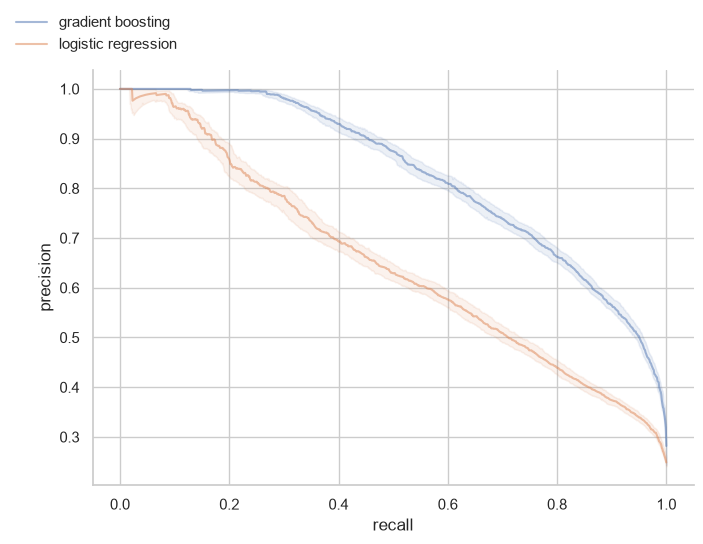

In [8]:
plot_pr(curves, hue="name", ci=0.90, recall_round=3, height=5, aspect=1.4)
plt.show()

The bands never touch. Whatever the resampled test set looks like, the
boosted model's curve stays above the linear one across the whole recall
range — this gap is not noise.

The band also widens to the right. At high recall the threshold is low, few
rows separate the models, and the metric is correspondingly less certain. A
single number hides that entirely.

## Average precision, as a distribution

The band above is pointwise. For a single summary number with an interval,
take average precision per replica and read its quantiles.

In [9]:
average_precision = (
    curves.sort_values("threshold")
    .groupby(["name", "replica"])["average_precision"]
    .first()
    .reset_index()
)
resampled = average_precision[average_precision["replica"] >= 0]

summary = resampled.groupby("name")["average_precision"].quantile([0.05, 0.5, 0.95]).unstack()
summary.columns = ["5th percentile", "median", "95th percentile"]
summary

,5th percentile,median,95th percentile
name,,,
gradient boosting,0.816,0.825,0.835
logistic regression,0.634,0.646,0.660


## The operating point

Metrics are not what ships; a threshold is. `at` finds the lowest threshold
whose precision clears a target, per replica, which turns a single operating
point into a distribution of them.

In [10]:
operating = at(curves, by=["name", "replica"], precision=0.80)
resampled_operating = operating[operating["replica"] >= 0]

(
    resampled_operating.groupby("name")[["threshold", "recall"]]
    .quantile([0.05, 0.5, 0.95])
    .rename_axis(["name", "quantile"])
)

threshold  recall
name                quantile                   
gradient boosting   0.050         0.521   0.593
                    0.500         0.544   0.614
                    0.950         0.564   0.639
logistic regression 0.050         0.593   0.227
                    0.500         0.643   0.263
                    0.950         0.681   0.309

Read the recall row: holding precision at 0.80, the boosted model catches
about 61% of high earners and the linear one about 27%, and neither interval
comes close to the other.

The threshold interval matters just as much in practice. It is the width of the
knob you are about to hard-code into a pipeline.

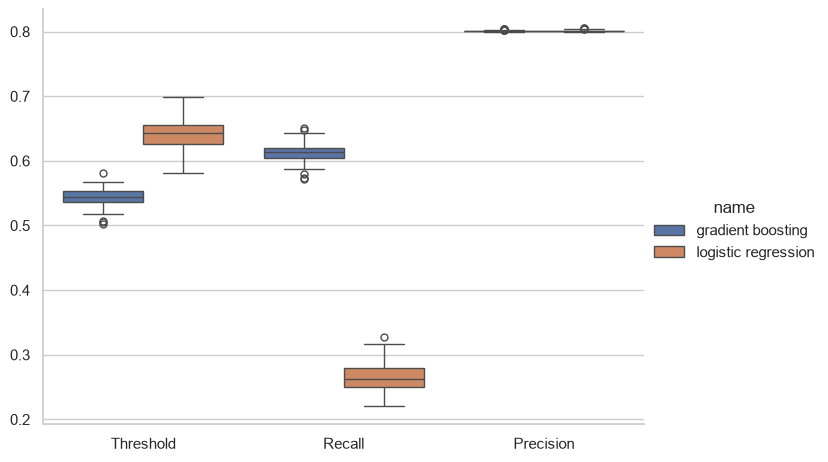

In [11]:
box_plot(
    resampled_operating,
    hue="name",
    values=("threshold", "recall", "precision"),
    height=5,
    aspect=1.4,
)
plt.show()

## Any statistic, not just these

Nothing above is special to precision and recall. The bootstrap output is a
normal DataFrame with a `replica` column, so any statistic you can compute per
group becomes a distribution with an interval — including ones `replicas` has
never heard of.

AUC, computed with scikit-learn on each replica:

In [12]:
auc = (
    replicas_frame[replicas_frame["replica"] >= 0]
    .groupby(["name", "replica"])[["positive", "prediction"]]
    .apply(lambda group: roc_auc_score(group["positive"], group["prediction"]))
    .rename("auc")
    .reset_index()
)

auc_summary = auc.groupby("name")["auc"].quantile([0.05, 0.5, 0.95]).unstack()
auc_summary.columns = ["5th percentile", "median", "95th percentile"]
auc_summary

,5th percentile,median,95th percentile
name,,,
gradient boosting,0.925,0.927,0.931
logistic regression,0.825,0.830,0.836


## What to take away

Every number in this notebook arrived with an interval, and the intervals are
what made the comparison decidable. The gap between these two models survives
resampling, so it is real. A gap whose bands overlapped would not have been,
and reporting it as a win would have been reporting noise.

The cost was one extra call. `bootstrap` runs on pandas, Polars, or Spark and
returns the same kind of frame it was given, so the same three lines work on a
test set that does not fit in memory.

Caveat worth keeping: these are percentile-bootstrap intervals, and their
coverage guarantee is asymptotic. On a small test set the interval can be
narrower than its nominal level. This test set has 14,653 rows, which is
comfortable — but the bands would deserve more suspicion at a few hundred.